In [49]:
### 

In [50]:
# This is a comment - python ignores everything after a '#' 
# Run this cell by clicking on the 'play' arrow in the upper right corner of the cell
# of typing <cntl><enter> (PC) or <cmd><enter> (mac)

# load some libraries we will need to manipulate data or plot
# functions from these libraries will have the prefixes listed after 'as'
# e.g. seaborn functions will look like: sns.catplot(...)
# the 'sns' tells you this is a seaborn function

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Plotting data with Python

This session is about plotting data with python.  There are several python libraries that are used for plotting.  These include:
- matplotlib.pyplot
- seaborn
- ggplot
- bokeh
- plotly

We will use matplotlib.pyplot and seaborn today.  If you are already an R user, you may be familiar with ggplot and you can use the python version.  If so, however, you already know how to do that.

**matplotlib** is a lower level set of plotting functions.  You can do a lot.  You can customize what you want. You might have to write lots of commands  

**seaborn** is a higher level set of plotting functions built on top of matplotlib.  You can make complex plots using relatively simple commands.  It is harder to do  customization.

## Visualization is important  

Modern methods of data analysis **require** you to look at your data at all stages of an analysis.

- Raw data
  - How are data distributed?
  - Are there any data problems? (outliers?  mistakes?)
  - Is variance changing over a range of performance?
  - Are there regions where this is no data
  - Are there points at the end of a range where important values have too much influence?
  - Plots:
    - histograms (distributions)
    - boxplots
    - scatterplots (for two variable relationships)  
<br></p>
   
- At each summary stage where you have an important result
  - For yourself: "What you see is what you get" principle.  Do you see the result you expect from your analysis when you visualize the data?  Do you know where a result comes from?
  - For others: Does the immediate visual impression back up the message you want people to take from your analysis?
  - Showing is often easier than text

In [51]:
wb = pd.read_csv("wellbeing.csv")

### See the top of the data (did it read in correctly?)

In [52]:
wb.head()

,Serial,WBOptimf,WBUseful,WBRelax,WBIntp,WBEnergy,WBDealpr,WBThkclr,WBGoodme,WBClsep,WBConfid,WBMkmind,WBLoved,WBIntthg,WBCheer
0,1087360,5,3,2,1,3,5,4,1,5,2,5,3,5,1
1,1094049,2,3,3,2,3,1,2,1,5,1,2,5,4,2
2,1094067,4,3,4,4,4,4,4,3,4,4,4,4,3,4
3,1097484,3,3,3,3,3,3,3,3,3,3,3,3,3,3
4,1102259,5,4,3,5,2,3,4,4,4,4,3,5,5,5


### Overall wellbeing
- We can calculate an overall well-being score based on a sum of all of the WB values
- We want a new data frame with just the participant ID and an overall well-being score

### Get participant ID for wellbeing data

In [53]:
ppt_id = wb["Serial"]
ppt_id.head()

0    1087360
1    1094049
2    1094067
3    1097484
4    1102259
Name: Serial, dtype: int64

### Get just well-being data so we can do sum across the rows

In [54]:
just_wb = wb.drop(columns=["Serial"]) # we could have more than one column between the brackets
just_wb.head()

,WBOptimf,WBUseful,WBRelax,WBIntp,WBEnergy,WBDealpr,WBThkclr,WBGoodme,WBClsep,WBConfid,WBMkmind,WBLoved,WBIntthg,WBCheer
0,5,3,2,1,3,5,4,1,5,2,5,3,5,1
1,2,3,3,2,3,1,2,1,5,1,2,5,4,2
2,4,3,4,4,4,4,4,3,4,4,4,4,3,4
3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
4,5,4,3,5,2,3,4,4,4,4,3,5,5,5


In [55]:
overall_wb = just_wb.sum(axis = 1) # axis = 1 means rows, axis = 0 means columns
# you can try with axis=0 to see what you get
overall_wb.head()

0    45
1    36
2    53
3    42
4    56
dtype: int64

In [56]:
wb = pd.DataFrame() # new data frame, ready to have stuff put in
wb["Serial"] = ppt_id # put in the participant ID
wb["overall_wb"] = overall_wb # put in the overall well-being value
wb.head()

,Serial,overall_wb
0,1087360,45
1,1094049,36
2,1094067,53
3,1097484,42
4,1102259,56


In [57]:
# read in participant characteristics (gender, minority status, deprived status)
ppt = pd.read_csv("participant_info.csv")
ppt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120115 entries, 0 to 120114
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   Serial    120115 non-null  int64
 1   male      120115 non-null  int64
 2   minority  120115 non-null  int64
 3   deprived  120115 non-null  int64
dtypes: int64(4)
memory usage: 3.7 MB


### Put participant information together with well-being data - A database 'merge'
#### This is an important operation to be familiar with

- Use an operation called 'merge' (or join)
- This is a basic operation from the database world

### Check on the length of the data and missing values

In [58]:
print("Length of well being data (including missing values): ",len(wb))
print("Length of well being data without missing well being values (if any): ",wb.count())

Length of well being data (including missing values):  102580
Length of well being data without missing well being values (if any):  Serial        102580
overall_wb    102580
dtype: int64


In [59]:
print("Length of participant data (including missing values): ",len(ppt))
print("Length of participant data without missing participant values (if any): ",ppt.count())

Length of participant data (including missing values):  120115
Length of participant data without missing participant values (if any):  Serial      120115
male        120115
minority    120115
deprived    120115
dtype: int64


### Missing values?

- Looks like we don't have missing values in either dataset
- The participant dataset is larger than the well-being dataset
- Perhaps some participants don't have well-being data

### Notice the 'Serial' column is there in both dataframes

This is the participant ID that we can use to match up data from different files.

### Put participant information together with well-being data

- Use an operation called 'merge' (or join)
- This is a basic operation from the database world

In [60]:
wb_ppt = ppt.merge(wb,how="inner",on=["Serial"])
wb_ppt.head()

,Serial,male,minority,deprived,overall_wb
0,1087360,0,0,0,45
1,1094049,0,0,0,36
2,1094067,0,0,0,53
3,1097484,0,1,1,42
4,1102259,0,0,0,56


In [61]:
len(wb_ppt)

102580

### Break that down

```
wb_ppt = ppt.merge(wb,how="inner",on=["Serial"])
```

- 'merge' is called as a 'method' using the ppt dataframe
- you call a method on a dataframe using a dot after the dataframe name and then the method name
- i.e. `data_frame_name(dot)method`
- `ppt.merge`
- calls the 'merge' method using the dataframe 'ppt'
</p>

- We want to merge 'ppt'  data with data from the dataframe 'wb'
  - We name 'wb' as the first argument
- 'how' tells us what to do with missing data
  - 'inner' means only include rows that have data in both datasets
  - 'outer' means include all rows from both datasets - put 'NaN' where data are missing
  - 'left means take all rows from the left dataset (neg_mood) and mark any missing values from flanker_rt with NaN
  - 'right means take all rows from the right dataset (flanker_rt) and mark any missing values from neg_mood with NaN
</p>

- **'on' says which column to use to match up the rows from the datasets**
  - We want to put together the data from the same participants
  - We use the participant ID for 'on'
    - You can use more than one column here

### Missing data

- Looks like all of the well-being participants are present
- So we didn't have any non-matches

### Add screen time

In [62]:
screen_t = pd.read_csv("screen_time.csv")
screen_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113359 entries, 0 to 113358
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Serial    113359 non-null  int64  
 1   Comph_we  113359 non-null  float64
 2   Comph_wk  113359 non-null  float64
 3   Comp_we   113359 non-null  float64
 4   Comp_wk   113359 non-null  float64
 5   Smart_we  113359 non-null  float64
 6   Smart_wk  113359 non-null  float64
 7   Watch_we  113359 non-null  float64
 8   Watch_wk  113359 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 7.8 MB


In [63]:
wb_ppt_st = wb_ppt.merge(screen_t, how="inner", on="Serial")
wb_ppt_st.head()

,Serial,male,minority,deprived,overall_wb,Comph_we,Comph_wk,Comp_we,Comp_wk,Smart_we,Smart_wk,Watch_we,Watch_wk
0,1087192,0,0,0,56,2.0,0.5,0.5,0.5,1.0,0.5,4.0,2.0
1,1087195,0,0,0,57,2.0,1.0,0.0,0.0,3.0,1.0,4.0,1.0
2,1087205,0,0,0,44,1.0,0.5,0.0,0.0,0.5,0.5,3.0,1.0
3,1087214,0,0,0,56,2.0,1.0,0.5,0.0,2.0,1.0,4.0,3.0
4,1087222,0,0,0,54,1.0,3.0,0.0,0.0,2.0,1.0,2.0,1.0


In [64]:
# put more understandable titles on columns
wb_ppt_st = wb_ppt_st.rename(columns = {"Comph_we" : "computer(we)",
                  "Comph_wk" : "computer(wd)",
                  "Comp_we" : "gaming(we)",
                  "Comp_wk" : "gaming(wd)",
                  "Smart_we" : "smartphone(we)",
                  "Smart_wk" : "smartphone(wd)",
                  "Watch_we" : "TV(we)",
                  "Watch_wk" : "TV(wd)"})
wb_ppt_st.head()

,Serial,male,minority,deprived,overall_wb,computer(we),computer(wd),gaming(we),gaming(wd),smartphone(we),smartphone(wd),TV(we),TV(wd)
0,1087192,0,0,0,56,2.0,0.5,0.5,0.5,1.0,0.5,4.0,2.0
1,1087195,0,0,0,57,2.0,1.0,0.0,0.0,3.0,1.0,4.0,1.0
2,1087205,0,0,0,44,1.0,0.5,0.0,0.0,0.5,0.5,3.0,1.0
3,1087214,0,0,0,56,2.0,1.0,0.5,0.0,2.0,1.0,4.0,3.0
4,1087222,0,0,0,54,1.0,3.0,0.0,0.0,2.0,1.0,2.0,1.0


### Our first plot - histogram/distribution plots

- How are the well being scores distributed?
- Reminder: 'sns' is the prefix for seaborn plotting routines

<Axes: xlabel='overall_wb', ylabel='Count'>

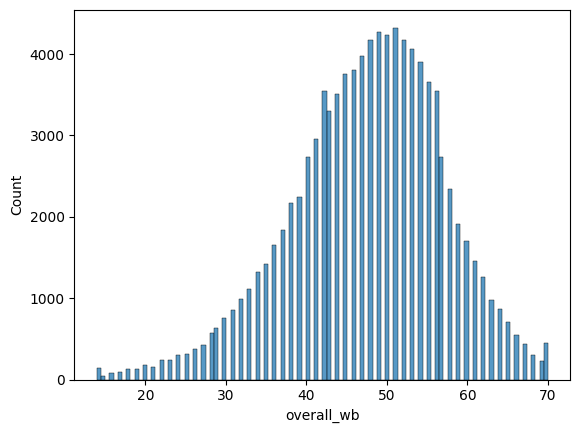

In [65]:
sns.histplot(wb_ppt_st["overall_wb"]) # notice we get the column we want using the name

### The bin size is arbitrary - if bin size is too big?
- Too big -- plot is too 'blocky' - you can't see the shape

<Axes: xlabel='overall_wb', ylabel='Count'>

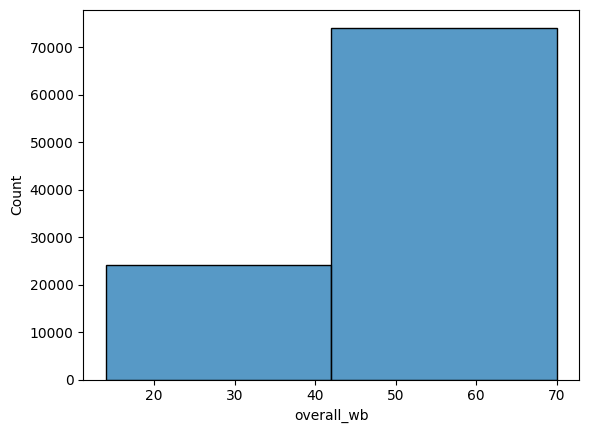

In [66]:
sns.histplot(wb_ppt_st["overall_wb"],bins = 2)

### If bin is too small?
- too small - for very continuous data each bin has one (or a few) counts
  - can't see shape either
- these data - discrete values, past a certain number of bins the plot doesn't change (space just gets added between the bin values)

### Plot the distribution of weekday smartphone hours

<Axes: xlabel='smartphone(wd)', ylabel='Count'>

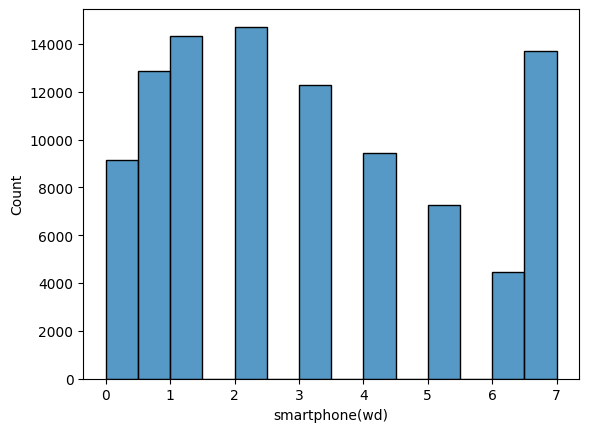

In [67]:
sns.histplot(wb_ppt_st["smartphone(wd)"],bins=np.arange(0,7.5,0.5))
# we want a bin for all possible values

### Plot weekend smartphone hours

<Axes: xlabel='smartphone(we)', ylabel='Count'>

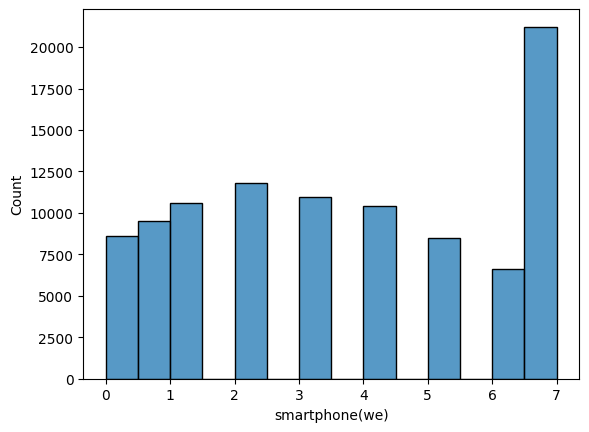

In [68]:
sns.histplot(wb_ppt_st["smartphone(we)"],bins=np.arange(0,7.5,0.5))

### What do you notice from these plots?
- **well-being** is pretty normal - a little skewed to the left (longer tail of low well-being scores)
- **screen time looks like it peaks at 2, but there is another peak at 7
  - light users (peak at 2)?
  - heavy users (>= 5)?

### Look at boxplots for screen time for different kinds of devices and for weekday/weekend

In [69]:
screens_df = wb_ppt_st.iloc[:,5:] # get just screen data
screens_df.head()

,computer(we),computer(wd),gaming(we),gaming(wd),smartphone(we),smartphone(wd),TV(we),TV(wd)
0,2.0,0.5,0.5,0.5,1.0,0.5,4.0,2.0
1,2.0,1.0,0.0,0.0,3.0,1.0,4.0,1.0
2,1.0,0.5,0.0,0.0,0.5,0.5,3.0,1.0
3,2.0,1.0,0.5,0.0,2.0,1.0,4.0,3.0
4,1.0,3.0,0.0,0.0,2.0,1.0,2.0,1.0


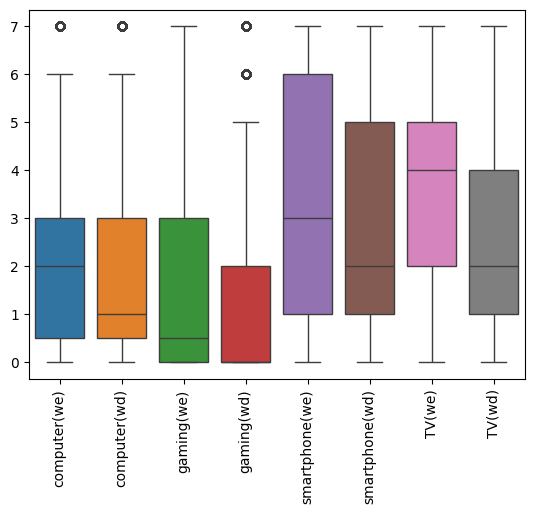

In [70]:
my_plot = sns.boxplot(data=screens_df)
my_plot.tick_params(axis='x', rotation=90) # rotate x-axis label so we can see it

#### Smartphones - more time than computers or gaming

### Make a violin plot instead (distribution on its side)

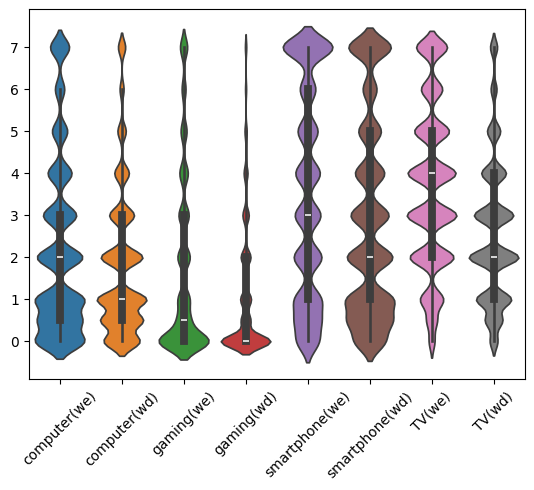

In [71]:
my_plot = sns.violinplot(data=screens_df) # bw_method=0.2 to smooth
my_plot.tick_params(axis='x', rotation=45)

#### What do you see?
- "squiggly" violin plots are due to discrete categories of time - continuous data will be smoother
- Smartphones have heavy users that other 'screens' don't have
- Gaming is relatively low level (could be a comparison category)
- Computers have similar low-level use -- not like smartphones (i.e. distribution at the low end)
  - e.g. if smartphones are actually made up of two distributions
  - (heavy and light users)
- TV has more use in the mid-range

### Barplot of weekday screen type of different types for males/females (see the article)
- Select weekday data only
- Plot separate bars for type of screen time and male/female

In [72]:
wb_ppt_st.head()

,Serial,male,minority,deprived,overall_wb,computer(we),computer(wd),gaming(we),gaming(wd),smartphone(we),smartphone(wd),TV(we),TV(wd)
0,1087192,0,0,0,56,2.0,0.5,0.5,0.5,1.0,0.5,4.0,2.0
1,1087195,0,0,0,57,2.0,1.0,0.0,0.0,3.0,1.0,4.0,1.0
2,1087205,0,0,0,44,1.0,0.5,0.0,0.0,0.5,0.5,3.0,1.0
3,1087214,0,0,0,56,2.0,1.0,0.5,0.0,2.0,1.0,4.0,3.0
4,1087222,0,0,0,54,1.0,3.0,0.0,0.0,2.0,1.0,2.0,1.0


In [73]:
# select weekday data
screens_wd = wb_ppt_st[["male","computer(wd)","gaming(wd)","smartphone(wd)","TV(wd)"]].copy()
# select the columns we want using the column names

print("***** Wide Data *****  types of screens are in different columns")
screens_wd.head()

***** Wide Data *****  types of screens are in different columns


,male,computer(wd),gaming(wd),smartphone(wd),TV(wd)
0,0,0.5,0.5,0.5,2.0
1,0,1.0,0.0,1.0,1.0
2,0,0.5,0.0,0.5,1.0
3,0,1.0,0.0,1.0,3.0
4,0,3.0,0.0,1.0,1.0


### Convert wide data to long format

In [74]:
# Command to convert wide data to long data

screens_wd_long = screens_wd.melt(id_vars=["male"],value_vars=["computer(wd)","gaming(wd)","smartphone(wd)","TV(wd)"],var_name="screen_type",
                              value_name="hours")
print("***** Long Data ***** Only one columns with times, types of screens are in different rows")
screens_wd_long.head()

***** Long Data ***** Only one columns with times, types of screens are in different rows


,male,screen_type,hours
0,0,computer(wd),0.5
1,0,computer(wd),1.0
2,0,computer(wd),0.5
3,0,computer(wd),1.0
4,0,computer(wd),3.0


### Long vs wide data

`screens_wd` is **wide** data
- Each person's data is a single line
- Different screen types are in different columns
</p>

`screens_wd_long` is **long** data
- Each **observation** is one line
- One person's data extends over several lines
- There is only one column for our value of interest
- There is a different column that says which screen type goes with the value

For plots where you need to group data, long format is often required.

### Make a barplot showing gender differences

[Text(0, 0.5, 'Daily digital screen engagement (hr)'),
 Text(0.5, 0, 'Screen type'),
 Text(0.5, 1.0, 'Hours of screen time on weekdays')]

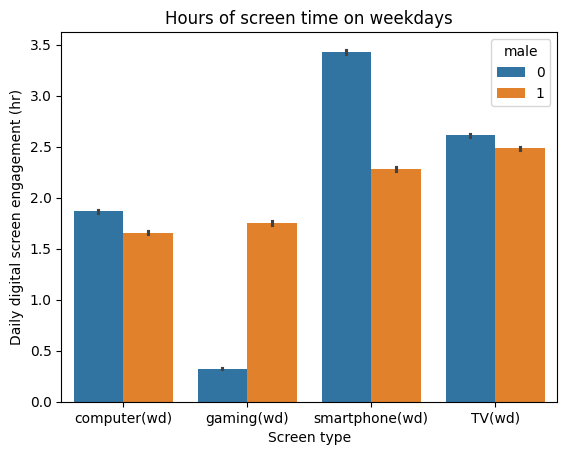

In [75]:
gender_barplot = sns.barplot(data=screens_wd_long, x="screen_type", y="hours", hue="male")
gender_barplot.set(ylabel = "Daily digital screen engagement (hr)",
                  xlabel = "Screen type",
                  title = "Hours of screen time on weekdays")

### Look at smartphone only on weekday/weekend and by gender (i.e. grouped by both gender and weekday/weekend)
- put genders in different bars
- put weekend/weekday in different plots

In [76]:
smartph_df = wb_ppt_st[["male","overall_wb","smartphone(we)","smartphone(wd)"]].copy()
smartph_long = smartph_df.melt(id_vars=["male","overall_wb"],
                               value_vars=["smartphone(we)","smartphone(wd)"],var_name="weekday_weekend",
                              value_name="hours")
smartph_long.head()

,male,overall_wb,weekday_weekend,hours
0,0,56,smartphone(we),1.0
1,0,57,smartphone(we),3.0
2,0,44,smartphone(we),0.5
3,0,56,smartphone(we),2.0
4,0,54,smartphone(we),2.0


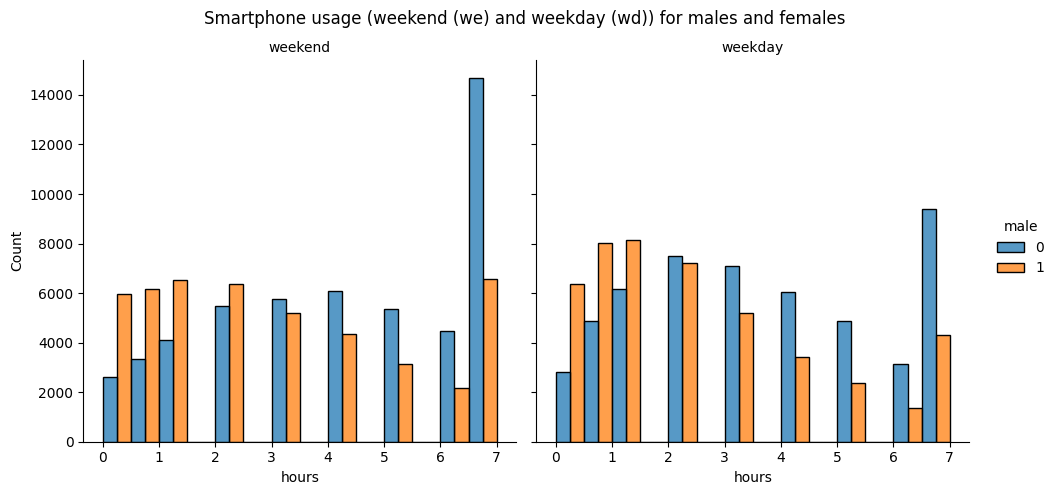

In [77]:
dplot = sns.displot(data=smartph_long, x="hours", 
            hue="male", # have different colored bars for 'male' variable
            col="weekday_weekend", # have separate plots for categories in 'we_wk' (weekend/weekday) variable
            bins=np.arange(0,7.5,0.5), # values are 0-7, we set bins to be 0-just before 7.5 
                                       # making a bin every 0.5 gives us space between the bars
            multiple="dodge" # put the bars next to each other (rather than on top of each other)
           )
my_fig = dplot.fig
my_fig.suptitle("Smartphone usage (weekend (we) and weekday (wd)) for males and females")
my_fig.subplots_adjust(top=0.88)
my_axes = dplot.axes
my_axes[0,0].title.set_text('weekend')
my_axes[0,1].title.set_text('weekday')


### What is the relationship between mental well-being and smartphone usage?
- Plot well-being for different levels of screen time
- Separate weekdays and weekends

[Text(0, 0.5, 'overall well-being score'),
 Text(0.5, 0, 'hours of smartphone use'),
 Text(0.5, 1.0, 'Well-being and hours of smartphone usage')]

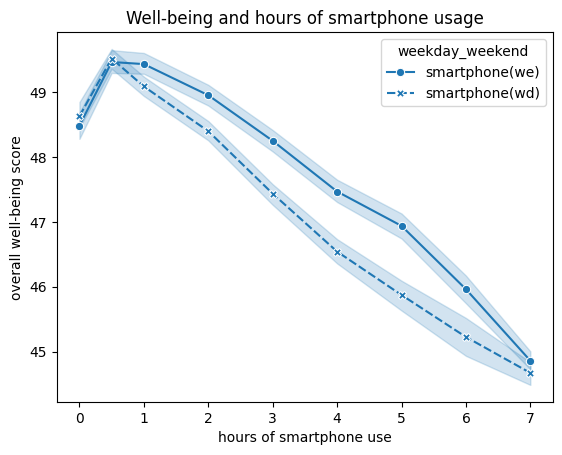

In [78]:
line_plot = sns.lineplot(data=smartph_long,x="hours",y="overall_wb",style="weekday_weekend",markers=True)
line_axes = line_plot.axes
line_axes.set(ylabel="overall well-being score", xlabel = "hours of smartphone use", title="Well-being and hours of smartphone usage")


#### Notice the scale on the y axis

### Plotting regression results
- We might want to do a regression on these results
- Plot scatterplot of raw data with linear model overlaid

/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<Axes: xlabel='hours', ylabel='overall_wb'>

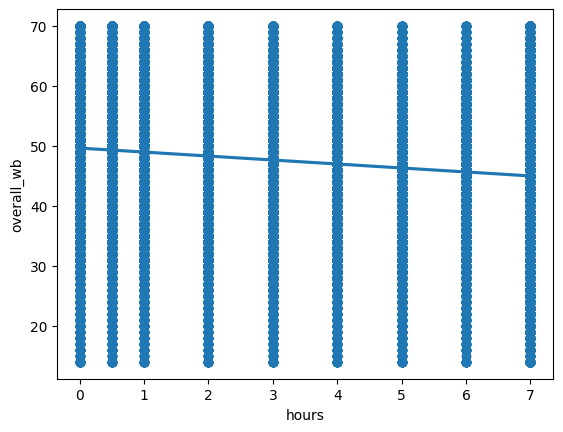

In [79]:
sns.regplot(data=smartph_long,x="hours",y="overall_wb")

### That's not very informative
- Discrete values and density of overplotting mean you can't see much from this

### What if we jitter the values?


<Axes: xlabel='hours', ylabel='overall_wb'>

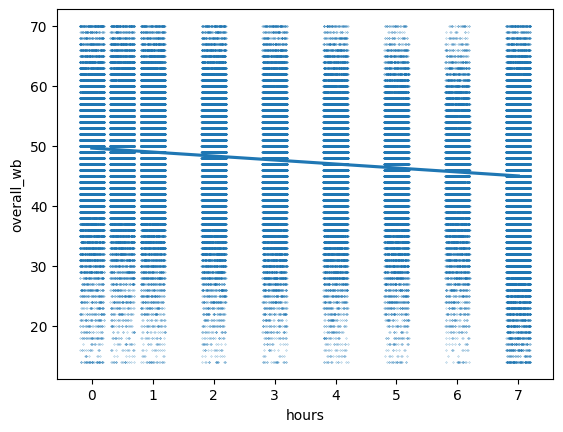

In [80]:
sns.regplot(data=smartph_long,x="hours",y="overall_wb",
           x_jitter=0.2, 
           scatter_kws={"s": .05}) # make the symbols very small

### A bit better, but still not very helpful -- plot the means for each discrete value of x

<Axes: xlabel='hours', ylabel='overall_wb'>

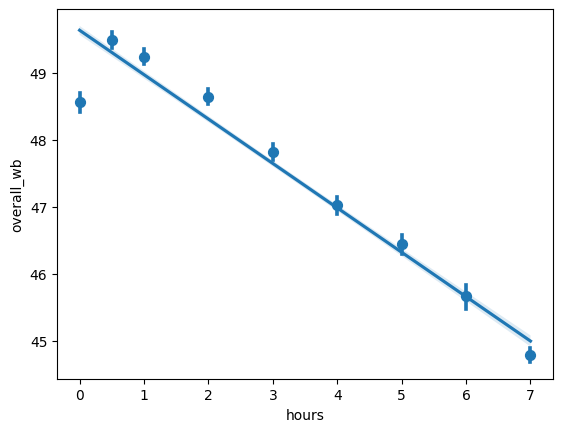

In [81]:
sns.regplot(data=smartph_long,x="hours",y="overall_wb", x_estimator=np.mean)

### Gaming data

In [82]:
gaming_df = wb_ppt_st[["male","overall_wb","gaming(we)","gaming(wd)"]].copy() # select data from overall dataframe
gaming_long = gaming_df.melt(id_vars=["male","overall_wb"],
                               value_vars=["gaming(we)","gaming(wd)"],var_name="weekday_weekend",
                              value_name="hours") # put data in long form
gaming_long.head()

,male,overall_wb,weekday_weekend,hours
0,0,56,gaming(we),0.5
1,0,57,gaming(we),0.0
2,0,44,gaming(we),0.0
3,0,56,gaming(we),0.5
4,0,54,gaming(we),0.0


/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/a.c.olson@bham.ac.uk/Documents/teach/IntroToDataScience/.venv_ex/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<Axes: xlabel='hours', ylabel='overall_wb'>

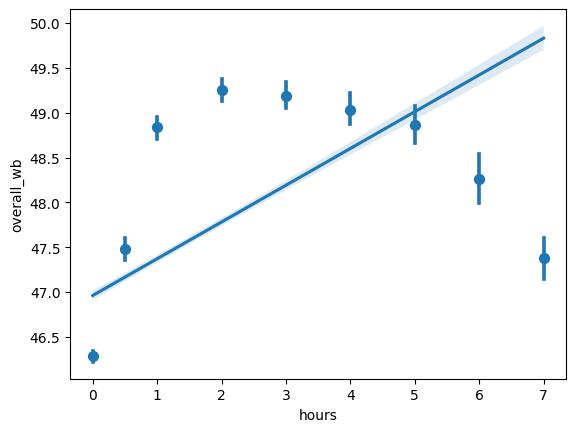

In [83]:
sns.regplot(data=gaming_long,x="hours",y="overall_wb", x_estimator=np.mean)

### That's not very good -- data don't look linear.  What about a quadratic fit?

<Axes: xlabel='hours', ylabel='overall_wb'>

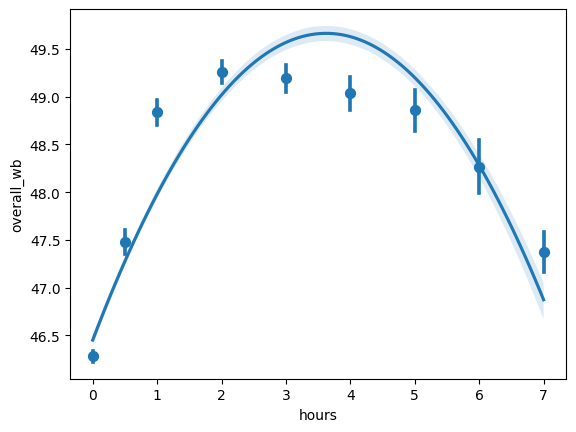

In [84]:
sns.regplot(data=gaming_long,x="hours",y="overall_wb", x_estimator=np.mean,order=2)

### This is why the authors considered this evidence for the "Godilocks principle"
- potential issues?
  - Range of changes compared to range of well-being values?
  - male/female general differences - who gamed long hours?
  - Number of people who gamed long hours?
  - Compare to smartphone result

### Putting several plots on a grid for one figure
- Set up 'axes' for a 2 x 2 figure
- Put a plot in each \[row,column\] position = four positions are:
```
[0,0]  [0,1]
[1,0]  [1,1]
```

In [ ]:
fig, axes = plt.subplots(2,2, # 5 rows, 2 columns
                         figsize=(10,10), # size of the whole figure, so each plots will be 5 x 5
                         sharey = True, # share common limits for the y axis
                         sharex = True # share common limits for the x axis
                         )
# for current_type in ["smartphone(wd)","gaming(wd)"]
# this produces a 2 x 2 matrix of axes that we can now fill with plots

fig.suptitle('Linear and quadratic fits for smartphone and videogame use') # overall title of figure

sns.regplot(ax=axes[0,0],data=smartph_long,x="hours",y="overall_wb", x_estimator=np.mean) # linear model for smartphone data
axes[0,0].set(title="linear - smartphone", xlabel=None, ylabel="overall well-being")
sns.regplot(ax=axes[0,1],data=smartph_long,x="hours",y="overall_wb", x_estimator=np.mean, order=2)
axes[0,1].set(title="quadratic - smartphone", xlabel=None, ylabel=None)
sns.regplot(ax=axes[1,0],data=gaming_long,x="hours",y="overall_wb", x_estimator=np.mean)
axes[1,0].set(title="linear - gaming", xlabel="hours", ylabel="overall well-being")
sns.regplot(ax=axes[1,1],data=gaming_long,x="hours",y="overall_wb", x_estimator=np.mean,order=2)
axes[1,1].set(title="quadratic - gaming", xlabel="hours", ylabel=None)


## Many types of plots are possible...

<img src="example_gallery_seaborn.png">

## Example gallery: [https://seaborn.pydata.org/examples/index.html]
## Tutorial: [https://seaborn.pydata.org/tutorial/introduction.html]

### Exercise: Do an examination of the computer data - How does it compare to gaming and smartphone data?